In [ ]:
import os
import random
import glob
import warnings
import numpy as np
from scipy import io
from tqdm import tqdm


from utils.plots import *
from utils.data import *
from utils.stats_perform import *
import utils.drl as utils
from utils.path import PathConfig,FigureWithData
from rl.agent import *
seed_value = 1234

np.random.seed(seed_value)
random.seed(seed_value)
warnings.filterwarnings("ignore")



fig_dir = os.path.join('figures', 'figure_S10')
data_fig_dir = os.path.join('data', 'source_data', 'figure_S10')
os.makedirs(fig_dir, exist_ok=True)
os.makedirs(data_fig_dir, exist_ok=True)

In [2]:
paths = PathConfig()
save_dir = paths.save_dir
g_dir = paths.g_dir

groups = ['control','lesion']
var_names = ['input_fr','da_conc','d1_occ','d2_occ']
colors_g = ['black','red','purple']
tr_rew = ['reward','omission']
tr_cs = ['90%','50%','10%']
f_size = 12
alpha_p = .05
max_trials = 200
n_samp = 3900
nf = [45,44]

## Analysis of biophysical simulations

This notebook reproduces the analysis performed on the output variables from the biophysical simulation.

**Note:** To plot and use the present notebook the user needs to download the data inside `raw_data` folder of the OSF repository. Look at  `download_data` for the code to do this.


### Additional information on data format: 

**Trial types**

- `1`:  90% rewarded
- `2`:  90% omission
- `3`:  50% rewarded
- `4`:  50% omission
- `5`:  10% rewarded
- `6`:  10% omission

Output variables from loading: 
- `mu_var_cells`: (N groups) x(N variables) x (N trialtypes) x (N reward types) x (N cells) x (N samples per trial) 
- `single_trial_var_cells`: (N groups) x(N variables) x (N trialtypes) x (N reward types) x (N cells) x (N samples per trial) x (N trials)

Where: 
- N groups = 2  (control, lesion)
- N variables = 4 (input firing rate, DA concentration, D1 occupancy, D2 occupancy)
- N trialtypes = 6 (90% reward, 50% reward, 10% reward)
- N reward types = 2 (rewarded, omission)
- N cells = 45, 44 for each group
- N samples per trial = 3900 (`n_samp`)

In [4]:

id_trial_plot = [[1,3,5],[2,4,6]] 
mu_var_cells = np.empty((len(groups),len (var_names),len(id_trial_plot),len(id_trial_plot[0]),45,n_samp))
single_trial_var_cells =  np.empty((len(groups),len(var_names),len(id_trial_plot),len(id_trial_plot[0]),45,n_samp,max_trials))
for ig in np.arange(len(groups)):
    data_path = os.path.join(g_dir,'raw_data', groups[ig])
    file_list = glob.glob(data_path + "/*.pickle")
    print('loading ' + groups[ig])
    file_list = file_list[:nf[ig]]
    for (id_unit) in  tqdm(range(len(file_list))):
        with open(file_list[id_unit], 'rb') as handle:
            unit = pickle.load(handle)
        trial_types, trial_names = unit['data']['TrialTypes'], unit['data']['TrialNames']
        temp = np.asarray(unit['simulation_results']['time_ax'])
        ind = np.unravel_index(np.argmax(temp, axis=None), temp.shape)
        for iv in np.arange(len(var_names)):
            var_name = var_names[iv]
            var = np.asarray(unit["simulation_results"][var_name])
            # exec('var = np.asarray(unit["simulation_results"].' + var_name + ')')
            time_ax = np.asarray(unit['simulation_results']['time_ax'])[:,ind[1]]
            for ir in np.arange(len(id_trial_plot)):
                for i in np.arange(len(id_trial_plot[ir])):
                    id_trials = np.argwhere(np.isin(trial_types, id_trial_plot[ir][i])==1)[:,0]
                    id_trials = id_trials[id_trials<max_trials]
                    var_trials = var[:,id_trials]
                    var_trials[var_trials<=0] = np.nan
                    if iv==1:
                        var_trials[var_trials>3000]=np.nan # TODO
                    elif iv>=2:
                        var_trials[var_trials>1]=np.nan
                    mu_var = np.nanmean(var_trials,axis=1)
                    mu_var_cells[ig,iv,ir,i,id_unit,:]=mu_var
                    single_trial_var_cells[ig,iv,ir,i,id_unit,:,0:var_trials.shape[1]]= var_trials
                    ids_ = [np.argwhere(ii==0).flatten() for ii in single_trial_var_cells[ig,iv,ir,i,id_unit,:,:].T]
                    for (ii,ids) in enumerate(ids_):
                        single_trial_var_cells[ig,iv,ir,i,id_unit,ids,ii] = np.nan

loading control


100%|██████████| 45/45 [00:05<00:00,  7.72it/s]


loading lesion


100%|██████████| 44/44 [00:05<00:00,  8.76it/s]


**Compute responses on epochs of interest**

Output variable:
- `trial_var_cells`: (N groups) x (N variables) x (N epochs) x (N cells) x (N trial types) x (N Trials)

Where: 
- N groups      = 2  (control, lesion)
- N variables   = 4 (input firing rate, DA concentration, D1 occupancy, D2 occupancy)
- N epochs      = 3 (CS, US, baseline)
- N trialtypes  = 6 (90% omission, 50% omission, 10% omission, 90% reward, 50% reward, 10% reward)
- N cells       = 45, 44 for each group
- N trials      = 200 (`max_trials`)

In [5]:
# Windows of responses : CS, US, baseline
window_lists = [[ [16,16.3],[18,18.3],[14.5,15.5]], [[15.8,16.8],[18,19],[14.5,15.5]]]  
idwindow = [0,1,1,1] # indeces of windows to use per variable (shorter for firing rates)
# Trial ids for  unrewarded| rewarded for each trial type
ir_it =[[1,0],[1,1],[1,2],[0,0],[0,1],[0,2]]
n_trial_types = 6
n_cells = 45
n_epochs = 3
trial_var_cells = np.empty((len(groups),len(var_names),n_epochs,n_cells,n_trial_types,max_trials))
for ig in np.arange(len(groups)):
    print(' ------------ Group : '+  groups[ig] + '------------')
    for iv in np.arange(4):
        window_list = window_lists[idwindow[iv]]
        print(' ------------ Variable : '+ var_names[iv] + '------------')
        for it in np.arange(n_trial_types):
            ir,ii = ir_it[it][0],ir_it[it][1] # unrewarded | rewarded
            var_trials = single_trial_var_cells[ig,iv,ir,ii,:,:,:]
            var_trials[var_trials<=0]=np.nan
            if iv>=2:
                var_trials[var_trials>1]=np.nan
            for iw in np.arange(len(window_list)):
                id_s = np.argwhere(time_ax>window_list[iw][0])[0]
                id_e = np.argwhere(time_ax>window_list[iw][1])[0]
                mu_epoch = np.nanmean(var_trials[:,np.arange(id_s[0],id_e[0]),:],axis=1)
                trial_var_cells[ig,iv,iw,:,it,0:mu_epoch.shape[1]] = mu_epoch

 ------------ Group : control------------
 ------------ Variable : input_fr------------
 ------------ Variable : da_conc------------
 ------------ Variable : d1_occ------------
 ------------ Variable : d2_occ------------
 ------------ Group : lesion------------
 ------------ Variable : input_fr------------
 ------------ Variable : da_conc------------
 ------------ Variable : d1_occ------------
 ------------ Variable : d2_occ------------


**Compute distribution of $\tau s$ based on single-cell responses**

For each group and neuron:  

1. Select independent variable = DA concentration (id = 1)
2. Select dependent variables = D1 occupancy for positive responses, D2 occupancy for negative responses
   
      Select the epoch responses at US and at baseline for each variable and perform baseline subtraction
3. Compute **utility axis** based on the mean across neurons and trials for the indpendent variable
4. Compute the **zero crossing points** for each single neuron 
5. Compute the **asymmetric learning rates** ($\alpha_i^+$,$\alpha_i^-$) for each single neuron using the zero crossing point from step (5). 
   
   The asymmetric scaling factors are computed using a linear and logarithmic scaling of the independent variable
6. Compute the **asymmetric scaling factor** ($\tau_i = \frac{\alpha_i^+}{\alpha_i^+ + \alpha_i^-}$) 


Output variables:

- `taus_v`:  distribution of $\tau_i$ for each neuron and each group (N cells x N groups)
- `taus_log`:  distribution of $\tau_i$ for each neuron and each group using a logarithmic scaling of DA concentration (N cells x N groups)
- `alpha_pos`:  distribution of $\alpha_i^+$ for each neuron and each group (N cells x N groups)
- `alpha_pos_log`:  distribution of $\alpha_i^+$ for each neuron and each group using a logarithmic scaling of DA concentration (N cells x N groups)
- `alpha_neg`:  distribution of $\alpha_i^-$ for each neuron and each group (N cells x N groups)
- `alpha_neg_log`:  distribution of $\alpha_i^-$ for each neuron and each group using a logarithmic scaling of DA concentration (N cells x N groups)

In [6]:


def compute_slope(xx, yy):
    id_keep = np.argwhere(~(np.isnan(xx) + np.isnan(yy)) == 1)[:, 0].flatten()
    res = stats.siegelslopes(yy[id_keep], xx[id_keep])
    return res[0]

n_cells = 45
i_win_base, i_win_us = 2, 1  # epoch indices
method_regress = 'siegelslopes'

ivar_pos = [0, 1, 2]
ivar_neg = [0, 1, 3]
n_vars = len(ivar_pos)

alpha_neg_v = np.nan*np.ones((n_vars, n_cells*2))
alpha_neg_log_v = np.nan*np.ones((n_vars, n_cells*2))
alpha_pos_v = np.nan*np.ones((n_vars, n_cells*2))
alpha_pos_log_v = np.nan*np.ones((n_vars, n_cells*2))

rpes_x = np.array([-0.9, -0.5, -0.1, 0.1, 0.5, 0.9])

for (iiv, (iv_pos, iv_neg)) in enumerate(zip(ivar_pos, ivar_neg)):
    tr_var_cells = trial_var_cells.copy()

    # Pool data across group 0 and group 1
    base_cells_pos = np.concatenate([
        tr_var_cells[0, iv_pos, i_win_base, :, :, :],
        tr_var_cells[1, iv_pos, i_win_base, :, :, :]
    ], axis=0)
    base_cells_neg = np.concatenate([
        tr_var_cells[0, iv_neg, i_win_base, :, :, :],
        tr_var_cells[1, iv_neg, i_win_base, :, :, :]
    ], axis=0)

    da_yy_pos = np.concatenate([
        tr_var_cells[0, iv_pos, i_win_us, :, :, :],
        tr_var_cells[1, iv_pos, i_win_us, :, :, :]
    ], axis=0)
    da_yy_neg = np.concatenate([
        tr_var_cells[0, iv_neg, i_win_us, :, :, :],
        tr_var_cells[1, iv_neg, i_win_us, :, :, :]
    ], axis=0)

    n_cells_total = da_yy_pos.shape[0]  # now 2 × n_cells

    # Prepare new alpha arrays for all pooled cells
    alpha_pos_cells = np.zeros(n_cells_total)
    alpha_pos_log_cells = np.zeros(n_cells_total)
    alpha_neg_cells = np.zeros(n_cells_total)
    alpha_neg_log_cells = np.zeros(n_cells_total)

    for i_cell in np.arange(n_cells_total):
        yy_db_pos = da_yy_pos[i_cell, :, :].flatten() - base_cells_pos[i_cell, :, :].flatten()
        yy_i_pos = da_yy_pos[i_cell, :, :].flatten()

        yy_db_neg = da_yy_neg[i_cell, :, :].flatten() - base_cells_neg[i_cell, :, :].flatten()
        yy_i_neg = da_yy_neg[i_cell, :, :].flatten()

        id_pos = np.argwhere(yy_db_pos > 0).flatten()
        id_neg = np.argwhere(yy_db_neg < 0).flatten()

        xx_i = np.repeat(rpes_x[:, None], da_yy_pos.shape[2], axis=1).flatten()
        bb_i_pos = base_cells_pos[i_cell, :, :].flatten()
        bb_i_neg = base_cells_neg[i_cell, :, :].flatten()

        xx_pos = xx_i[id_pos]
        yy_pos = yy_i_pos[id_pos] - bb_i_pos[id_pos]
        yy_pos_log = np.log10(yy_i_pos[id_pos] / bb_i_pos[id_pos])

        xx_neg = xx_i[id_neg]
        yy_neg = yy_i_neg[id_neg] - bb_i_neg[id_neg]
        yy_neg_log = np.log10(yy_i_neg[id_neg] / bb_i_neg[id_neg])

        # Compute slopes
        alpha_pos = compute_slope(xx_pos, yy_pos)
        alpha_pos_log = compute_slope(xx_pos, yy_pos_log)
        alpha_neg = compute_slope(-xx_neg, -yy_neg)
        alpha_neg_log = compute_slope(-xx_neg, -yy_neg_log)

        alpha_pos_cells[i_cell] = alpha_pos
        alpha_pos_log_cells[i_cell] = alpha_pos_log
        alpha_neg_cells[i_cell] = alpha_neg
        alpha_neg_log_cells[i_cell] = alpha_neg_log

    # Save only first n_cells for compatibility
    alpha_pos_v[iiv, :] = alpha_pos_cells
    alpha_pos_log_v[iiv, :] = alpha_pos_log_cells
    alpha_neg_v[iiv, :] = alpha_neg_cells
    alpha_neg_log_v[iiv, :] = alpha_neg_log_cells


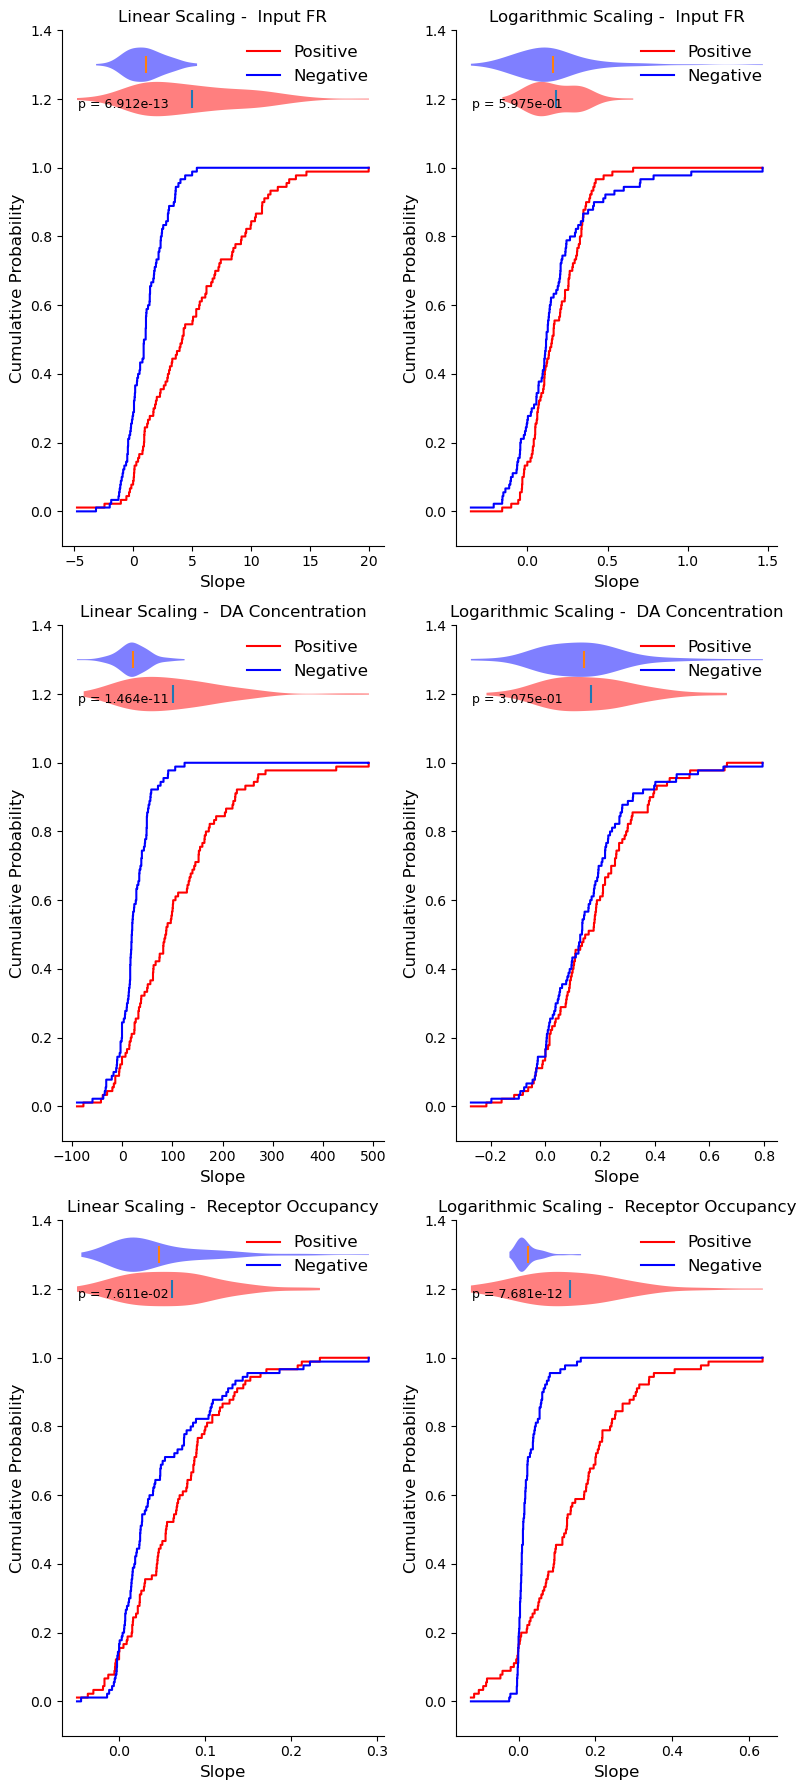

Saved figure to figures/figure_S10/figure_s10.pdf
Saved data and stats to data/figure_data/figure_S10/figure_s10.txt


In [13]:
from scipy.stats import ks_2samp
from scipy.stats import ttest_ind

var_names = ['Input FR','DA Concentration','Receptor Occupancy']
fig, ax = plt.subplots(3, 2, figsize=(8, 18))
nbins=1000
for (iiv, (iv_pos, iv_neg)) in enumerate(zip(ivar_pos, ivar_neg)):
    # Linear scaling
    bins = np.linspace(np.min([alpha_pos_v[iiv, :], alpha_neg_v[iiv, :]]),
                       np.max([alpha_pos_v[iiv, :], alpha_neg_v[iiv, :]]),
                       nbins)

    counts_pos, bin_edges = np.histogram(alpha_pos_v[iiv, :], bins=bins, density=True)
    counts_neg, _ = np.histogram(alpha_neg_v[iiv, :], bins=bins, density=True)

    cdf_pos = np.cumsum(counts_pos) * np.diff(bin_edges)
    cdf_neg = np.cumsum(counts_neg) * np.diff(bin_edges)

    # CDF step plots
    # ax[iiv, 0].plot([np.nanmedian(alpha_neg_v), np.nanmedian(alpha_neg_v)], [0, 1], color='blue', linestyle='--')
    # ax[iiv, 0].plot([np.nanmedian(alpha_pos_v), np.nanmedian(alpha_pos_v)], [0, 1], color='red', linestyle='--')
    ax[iiv, 0].step(bin_edges[:-1], cdf_pos, where='post', color='red', label='Positive')
    ax[iiv, 0].step(bin_edges[:-1], cdf_neg, where='post', color='blue', label='Negative')
    ax[iiv, 0].set_title(f'Linear Scaling -  {var_names[iiv]}')
    plot_config(ax[iiv, 0], 'Slope','Cumulative Probability',12,True)

    # KS test
    ks_stat, p_value = ttest_ind(alpha_pos_v[iiv, :], alpha_neg_v[iiv, :])
    ax[iiv, 0].text(0.05, 0.85, f'p = {p_value:.3e}', transform=ax[iiv, 0].transAxes, fontsize=9)

    # Violin plots (horizontal)
    parts_pos = ax[iiv, 0].violinplot(alpha_pos_v[iiv, :], positions=[1.2], vert=False, widths=0.1, showmeans=True, showextrema=False, showmedians=False)
    parts_neg = ax[iiv, 0].violinplot(alpha_neg_v[iiv, :], positions=[1.3], vert=False, widths=0.1, showmeans=True, showextrema=False, showmedians=False)

    for pc in parts_pos['bodies']:
        pc.set_facecolor('red')
        pc.set_alpha(0.5)
    for pc in parts_neg['bodies']:
        pc.set_facecolor('blue')
        pc.set_alpha(0.5)

    ax[iiv, 0].set_ylim([-0.1, 1.4])  # Extra space for violins

    # --- Log scaling
    bins_log = np.linspace(np.min([alpha_pos_log_v[iiv, :], alpha_neg_log_v[iiv, :]]),
                           np.max([alpha_pos_log_v[iiv, :], alpha_neg_log_v[iiv, :]]),
                           nbins)

    counts_pos_log, bin_edges_log = np.histogram(alpha_pos_log_v[iiv, :], bins=bins_log, density=True)
    counts_neg_log, _ = np.histogram(alpha_neg_log_v[iiv, :], bins=bins_log, density=True)

    cdf_pos_log = np.cumsum(counts_pos_log) * np.diff(bin_edges_log)
    cdf_neg_log = np.cumsum(counts_neg_log) * np.diff(bin_edges_log)

    # CDFs for log
    ax[iiv, 1].step(bin_edges_log[:-1], cdf_pos_log, where='post', color='red', label='Positive')
    ax[iiv, 1].step(bin_edges_log[:-1], cdf_neg_log, where='post', color='blue', label='Negative')
    ax[iiv, 1].set_title(f'Logarithmic Scaling -  {var_names[iiv]}')
    plot_config(ax[iiv, 1], 'Slope','Cumulative Probability',12,True)


    #  test log
    ks_stat_log, p_value_log = ttest_ind(alpha_pos_log_v[iiv, :], alpha_neg_log_v[iiv, :])
    ax[iiv, 1].text(0.05, 0.85, f'p = {p_value_log:.3e}', transform=ax[iiv, 1].transAxes, fontsize=9)

    # Violin plots (log)
    parts_pos_log = ax[iiv, 1].violinplot(alpha_pos_log_v[iiv, :], positions=[1.2], vert=False, widths=0.1, showmeans=True, showextrema=False, showmedians=False)
    parts_neg_log = ax[iiv, 1].violinplot(alpha_neg_log_v[iiv, :], positions=[1.3], vert=False, widths=0.1, showmeans=True, showextrema=False, showmedians=False)

    for pc in parts_pos_log['bodies']:
        pc.set_facecolor('red')
        pc.set_alpha(0.5)
    for pc in parts_neg_log['bodies']:
        pc.set_facecolor('blue')
        pc.set_alpha(0.5)

    ax[iiv, 1].set_ylim([-0.1, 1.4])  # Extra space for violins

plt.tight_layout()
plt.show()

# Wrap figure
fig_data = FigureWithData(fig)

# Linear scaling panels
for iiv, var_name in enumerate(['Input FR', 'DA Concentration', 'Receptor Occupancy']):
    linear_data = np.column_stack((
        alpha_pos_v[iiv, :],
        alpha_neg_v[iiv, :]
    ))
    fig_data.add_data(
        f"Linear Scaling - {var_name}",
        linear_data,
        ['Positive Slopes', 'Negative Slopes']
    )

# Log scaling panels
for iiv, var_name in enumerate(['Input FR', 'DA Concentration', 'Receptor Occupancy']):
    log_data = np.column_stack((
        alpha_pos_log_v[iiv, :],
        alpha_neg_log_v[iiv, :]
    ))
    fig_data.add_data(
        f"Log Scaling - {var_name}",
        log_data,
        ['Positive Slopes (Log)', 'Negative Slopes (Log)']
    )


# Save everything
fig_data.save(
    base_filename='figure_s10',
    folder_data= data_fig_dir,
    folder_figures= fig_dir
)

